Top 3 Most Common Cuisines:
 Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

Top 3 Cuisines as Percentage of Total Restaurants:
 Cuisines
North Indian    20.09
Chinese         13.88
Fast Food       10.08
Name: count, dtype: float64


<Axes: title={'center': 'Top 3 Cuisines'}, xlabel='Cuisines', ylabel='Number of Restaurants'>

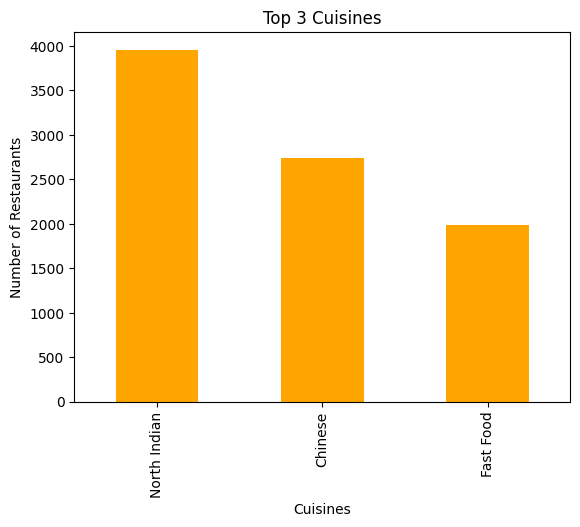

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload

df = pd.read_csv("Dataset .csv")
df.head()

df.columns

#LEVEL 1: TASK 1-Top Cuisines
df = df.dropna(subset=['Cuisines'])
df['Cuisines'] = df['Cuisines'].str.split(', ')
df_exploded = df.explode('Cuisines')

top_cuisines = df_exploded['Cuisines'].value_counts()

#T1P1
top_3 = top_cuisines.head(3)
print("Top 3 Most Common Cuisines:\n", top_3)

total = len(df_exploded)

#T1P2
top_3_percent = (top_3 / total) * 100
top_3_percent = top_3_percent.round(2)

print("\nTop 3 Cuisines as Percentage of Total Restaurants:\n", top_3_percent)

#Visualisation of the Analysis
top_3.plot(kind='bar', title="Top 3 Cuisines", ylabel="Number of Restaurants", color='orange')


City with the most restaurants: New Delhi (5473 restaurants)


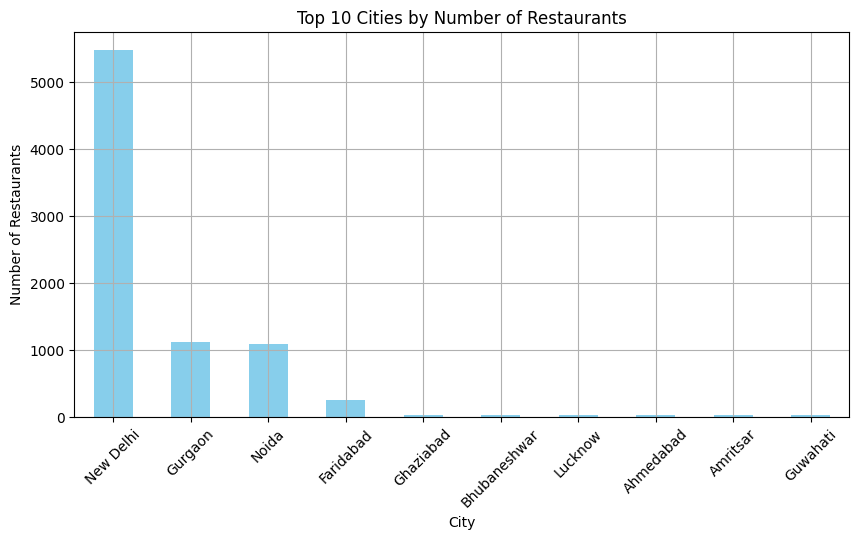

City with the highest average rating (10+ restaurants): London (4.54)


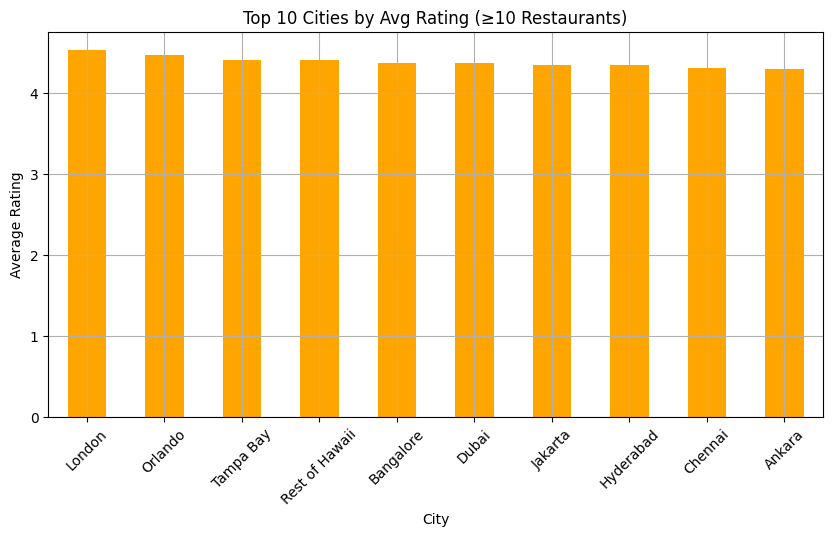

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload

df = pd.read_csv("Dataset .csv")
df.head()

#LEVEL 1: TASK 2-City Analysis
#T2P1
# Count number of restaurants in each city
city_counts = df['City'].value_counts()

# Top city
most_restaurants_city = city_counts.idxmax()
most_restaurants_count = city_counts.max()

print(f"City with the most restaurants: {most_restaurants_city} ({most_restaurants_count} restaurants)")

#Visualization of the top cities
city_counts.head(10).plot(kind='bar', figsize=(10,5), color='skyblue', title='Top 10 Cities by Number of Restaurants')
plt.ylabel("Number of Restaurants")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#T2P2
df.columns

# Grouping by city
city_grouped = df.groupby('City').agg(
    num_restaurants=('Aggregate rating', 'count'),
    avg_rating=('Aggregate rating', 'mean')
)
filtered_cities = city_grouped[city_grouped['num_restaurants'] >= 10]

# Sorting by average rating
sorted_avg_rating = filtered_cities.sort_values(by='avg_rating', ascending=False)

# Top city with highest average rating
top_avg_city = sorted_avg_rating.head(1)
top_city = top_avg_city.index[0]
top_rating = top_avg_city['avg_rating'].values[0]

print(f"City with the highest average rating (10+ restaurants): {top_city} ({top_rating:.2f})")

#Visualisation of the average rating of cities
sorted_avg_rating.head(10)['avg_rating'].plot(kind='bar', color='orange', figsize=(10,5), title='Top 10 Cities by Avg Rating (≥10 Restaurants)')
plt.ylabel("Average Rating")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


<bound method Series.unique of 0       3
1       3
2       4
3       4
4       4
       ..
9546    3
9547    3
9548    4
9549    4
9550    2
Name: Price range, Length: 9551, dtype: int64>
Number of Restaurants in Each Price Range:
 Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Percentage of Restaurants in Each Price Range:
 Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


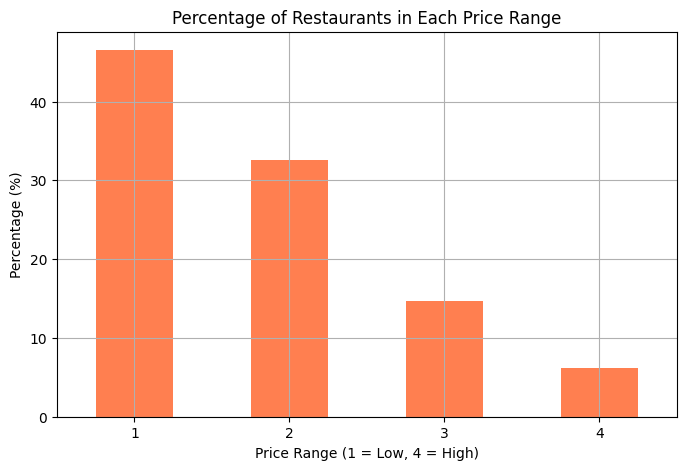

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload

df = pd.read_csv("Dataset .csv")
df.head()

#LEVEL 1: TASK 3- Price Range Distribution
df.columns
#Price range
print(df['Price range'].unique)

#cleaning of data
df = df.dropna(subset=['Price range'])
df['Price range'] = pd.to_numeric(df['Price range'])

dfn= df.dropna(subset=['Price range'])

price_counts = df['Price range'].value_counts().sort_index()

# Calculate percentage
price_percent = (price_counts / len(df)) * 100
price_percent = price_percent.round(2)

print("Number of Restaurants in Each Price Range:\n", price_counts)
print("\nPercentage of Restaurants in Each Price Range:\n", price_percent)

#Visualisation of the analyzed(percentage bar chart)
plt.figure(figsize=(8,5))
price_percent.plot(kind='bar', color='coral')
plt.title("Percentage of Restaurants in Each Price Range")
plt.xlabel("Price Range (1 = Low, 4 = High)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()




📦 Percentage of Restaurants Offering Online Delivery:
Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64


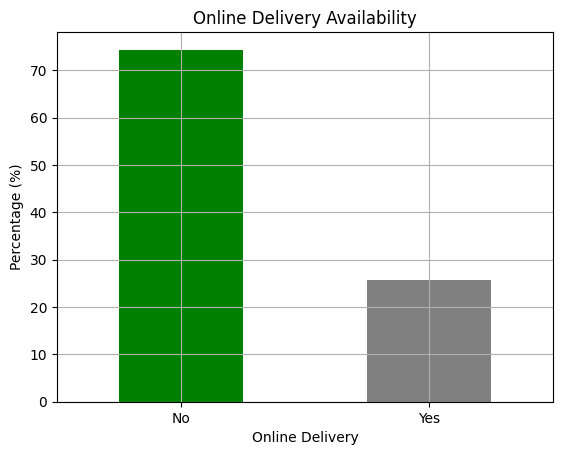


Average Rating by Online Delivery:
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


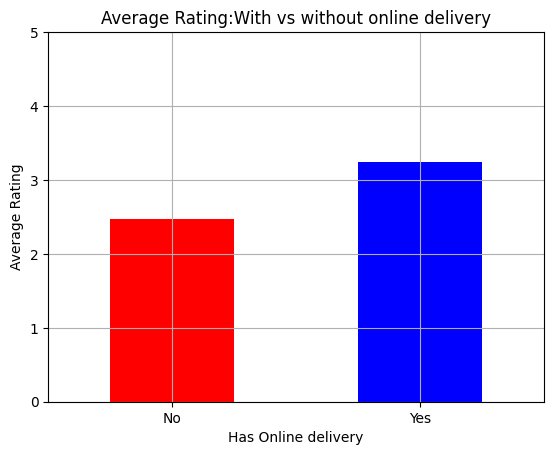

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload

df = pd.read_csv("Dataset .csv")
df.head()

#LEVEL 1: TASK 4-Online Delivery
df.columns
#Has Online delivery
#Is delivering now
#Aggregate rating

# Dropping rowa that have null values
df = df.dropna(subset=['Has Online delivery', 'Aggregate rating'])

# Convert Rating to numeric
df['Aggregate rating'] = pd.to_numeric(df['Aggregate rating'], errors='coerce')
df['Has Online delivery'] = df['Has Online delivery'].str.lower().map({'yes': 'Yes', 'no': 'No', 'Yes': 'Yes', 'No': 'No'})

#part1
online_delivery_counts = df['Has Online delivery'].value_counts()
total = online_delivery_counts.sum()
online_percent = (online_delivery_counts / total) * 100
online_percent = online_percent.round(2)

print("📦 Percentage of Restaurants Offering Online Delivery:")
print(online_percent)

#Visualisation of part1
online_percent.plot(kind='bar', color=['green', 'grey'], title='Online Delivery Availability')
plt.ylabel('Percentage (%)')
plt.xlabel('Online Delivery')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

#part2
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print("\nAverage Rating by Online Delivery:")
print(avg_rating_delivery)

#visualisation of part2
avg_rating_delivery.plot(kind='bar', color=['Red', 'Blue'], title='Average Rating:With vs without online delivery')
plt.ylabel('Average Rating')
plt.xlabel('Has Online delivery')
plt.xticks(rotation=0)
plt.ylim(0,5)
plt.grid(True)
plt.show()

Rating Range
0–1    2148
1–2      10
2–3    1891
3–4    4388
4–5    1114
Name: count, dtype: int64


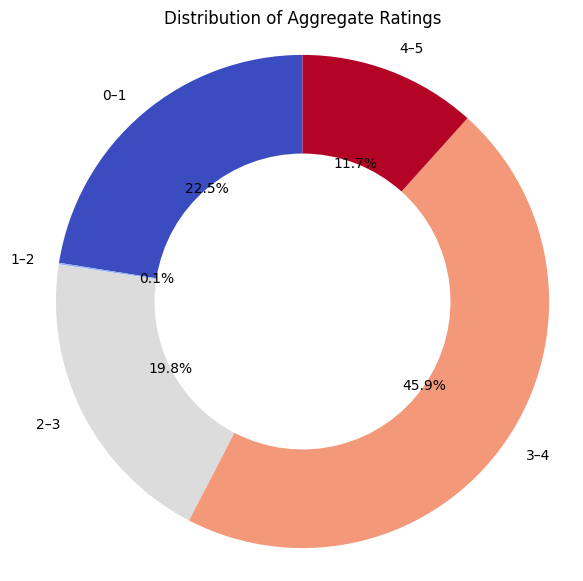

Average number of votes per restaurant: 156.91


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import numpy as np

from wordcloud import WordCloud

from google.colab import files
uploaded = files.upload

df = pd.read_csv("Dataset .csv")
df.head()

#LEVEL 2: TASK 1-Restaurants Rating
df.columns

# Creating the bins and labels for rating ranges
bins = [0, 1, 2, 3, 4, 5]
labels = ['0–1', '1–2', '2–3', '3–4', '4–5']
df['Rating Range'] = pd.cut(df['Aggregate rating'], bins=bins, labels=labels, include_lowest=True)

rating_counts = df['Rating Range'].value_counts().sort_index()
print(rating_counts)

#Visualisation of the required the analysis data
#Donut chart
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rating_counts)))

plt.figure(figsize=(7, 7))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'width': 0.4})
plt.title("Distribution of Aggregate Ratings")
plt.axis('equal')
plt.show()

average_votes = df['Votes'].mean()
print("Average number of votes per restaurant:", round(average_votes, 2))



Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


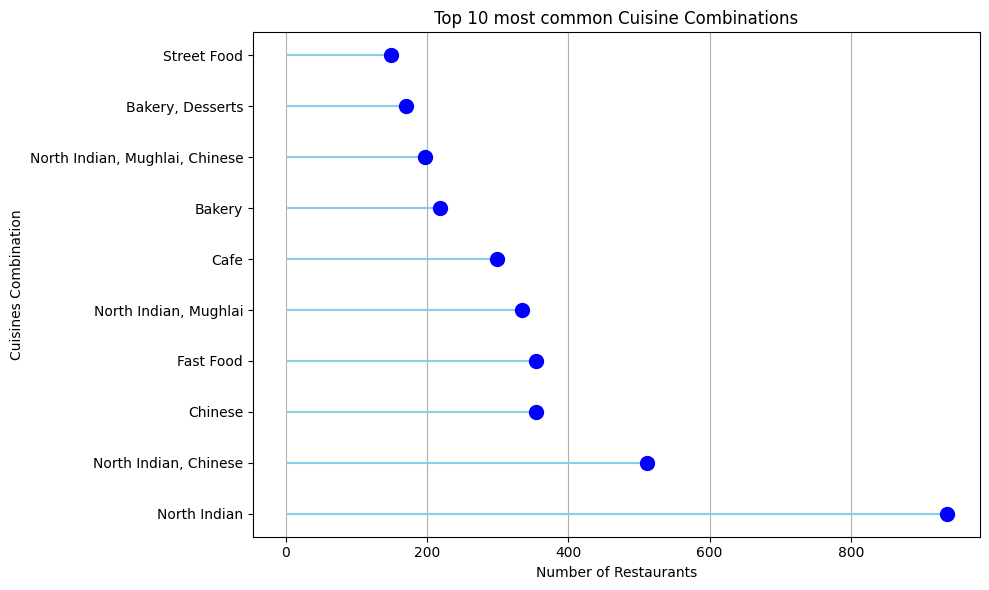

Cuisines
Afghani                                      0.725
Afghani, Mughlai, Chinese                    0.000
Afghani, North Indian                        0.000
Afghani, North Indian, Pakistani, Arabian    0.000
African                                      4.700
                                             ...  
Western, Asian, Cafe                         4.200
Western, Fusion, Fast Food                   3.200
World Cuisine                                4.900
World Cuisine, Mexican, Italian              4.400
World Cuisine, Patisserie, Cafe              4.200
Name: Aggregate rating, Length: 1825, dtype: float64


/tmp/ipython-input-18-2632918911.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df_top10, x='Aggregate rating', y='Cuisines', palette='viridis')
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 70.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 62.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 72.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/di

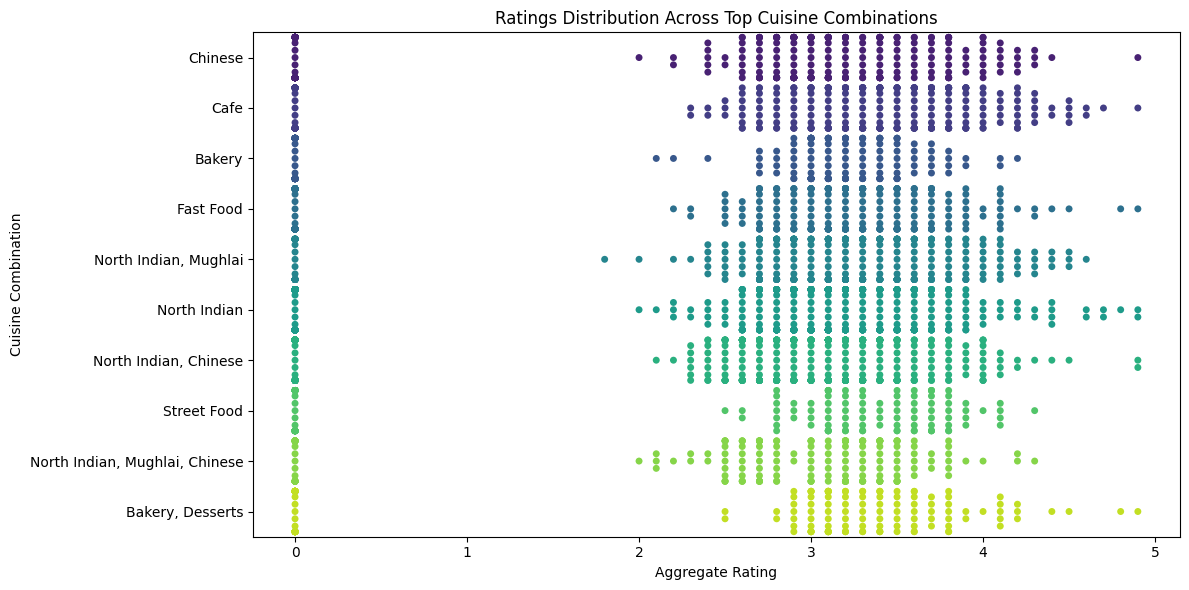

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")

#LEVEL 2: TASK 2-Cuisine Combination
df.columns
#Cuisines

top_cuisines = df['Cuisines'].value_counts().head(10)
print(top_cuisines)

#Visualisation of the required analysis data
#Horizontal Lollipop Chart
plt.figure(figsize=(10,6))
plt.hlines(y=top_cuisines.index, xmin=0, xmax=top_cuisines, color='skyblue')
plt.plot(top_cuisines, top_cuisines.index, 'o', markersize=10, color='blue')
plt.title("Top 10 most common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisines Combination")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

#Cuisines Combination
avg_rating_per_cuisine = df.groupby('Cuisines')['Aggregate rating'].mean()
print(avg_rating_per_cuisine)


#Visualisation of the required analysis data
#swarmplot
top10_cuisines = top_cuisines.index.tolist()
df_top10 = df[df['Cuisines'].isin(top10_cuisines)]

plt.figure(figsize=(12, 6))
sns.swarmplot(data=df_top10, x='Aggregate rating', y='Cuisines', palette='viridis')
plt.title("Ratings Distribution Across Top Cuisine Combinations")
plt.xlabel("Aggregate Rating")
plt.ylabel("Cuisine Combination")
plt.tight_layout()
plt.show()



City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64


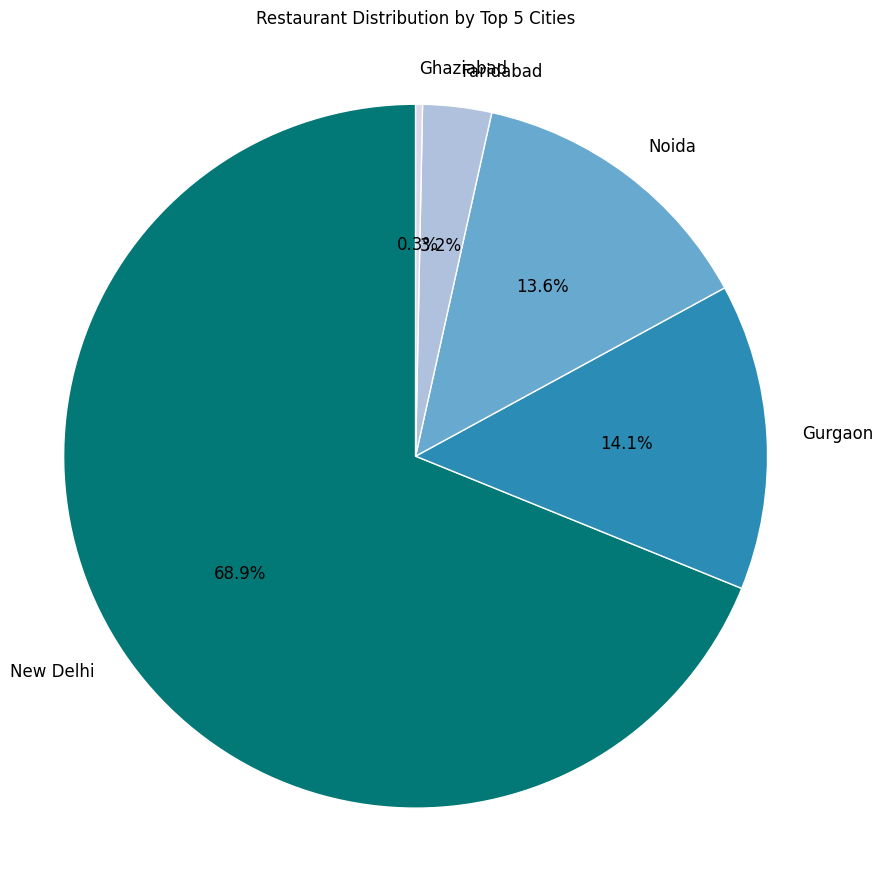

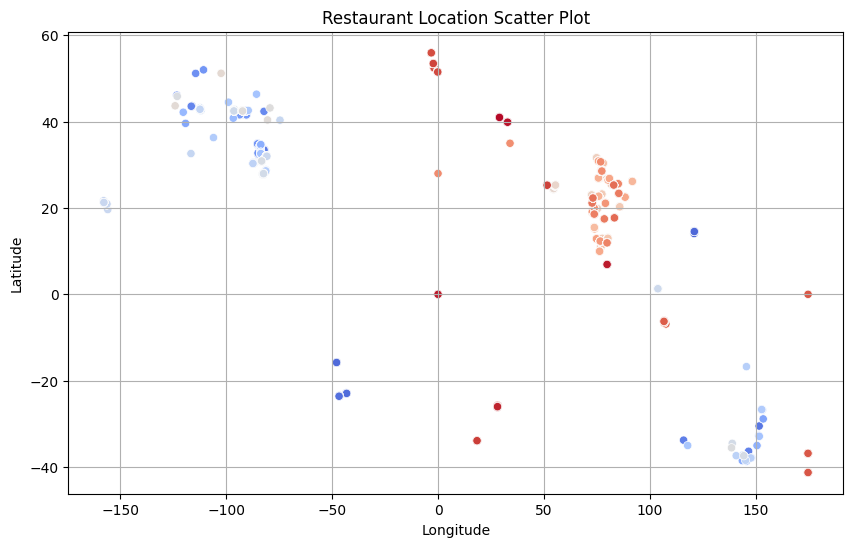

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")
df.columns
#City

#LEVEL 2: TASK 3-Geographic Analysis
top_cities = df['City'].value_counts().head(5)
print(top_cities)

#piechart
# Plot Pie chart of top 5 cities
colors = plt.cm.PuBuGn_r(np.linspace(0.2, 0.8, len(top_cities)))

plt.figure(figsize=(9, 9))
plt.pie(
    top_cities,
    labels=top_cities.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Restaurant Distribution by Top 5 Cities")
plt.axis('equal')
plt.tight_layout()
plt.show()

#For location clusters
# Plotting restaurant locations to identify clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='City', legend=False, palette='coolwarm')
plt.title("Restaurant Location Scatter Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()



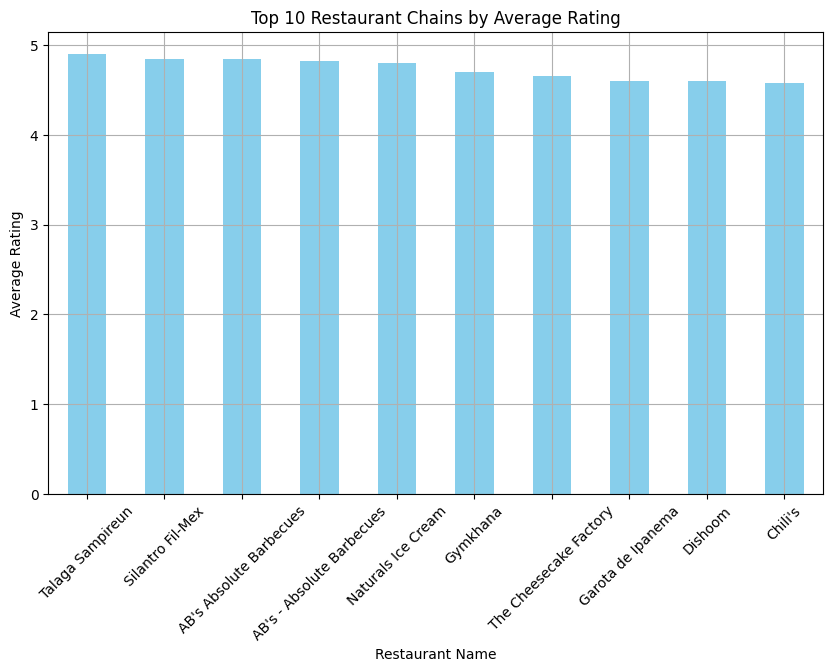

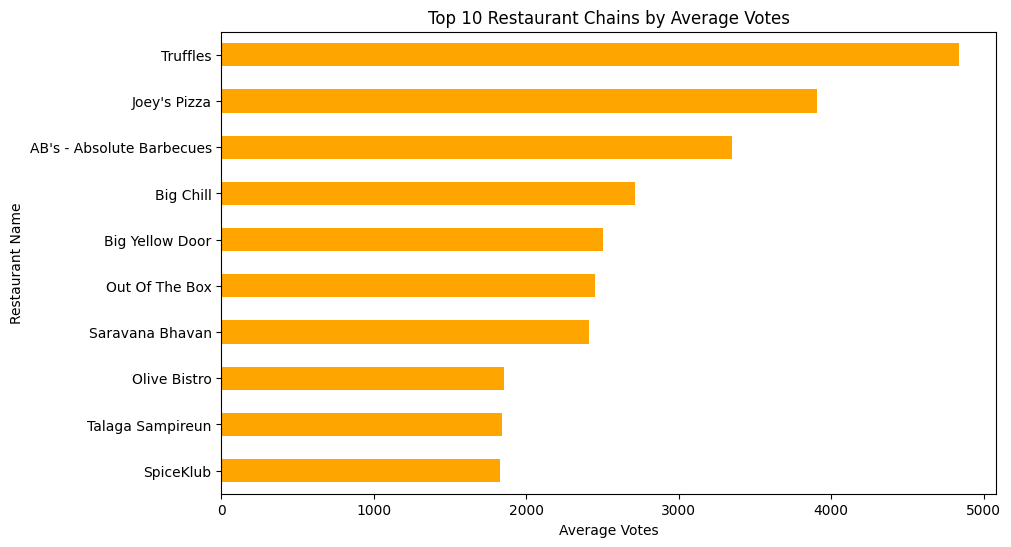

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")
df.head()

df.columns
#Restaurants Name

#LEVEL 2: TASK 4-Restaurants Chains

#Identifying the restaurants chains
chain_counts = df['Restaurant Name'].value_counts()
restaurant_chains = chain_counts[chain_counts >1]
restaurant_chains_df = df[df['Restaurant Name'].isin(restaurants_chains.index)]

#Average Rating
avg_rating = restaurant_chains_df.groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False)

#Average Votes
avg_votes = restaurant_chains_df.groupby('Restaurant Name')['Votes'].mean().sort_values(ascending=False)

#Visualisation of the analyzed data
plt.figure(figsize=(10, 6))
avg_rating.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Restaurant Chains by Average Rating')
plt.xlabel("Restaurant Name")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
avg_votes.head(10).plot(kind='barh', color='orange')
plt.title('Top 10 Restaurant Chains by Average Votes')
plt.xlabel('Average Votes')
plt.gca().invert_yaxis()
plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


  Rating text       tokens
0   Excellent  [excellent]
1   Excellent  [excellent]
2   Very Good       [good]
3   Excellent  [excellent]
4   Excellent  [excellent]
Top Positive Words: [('good', 3179), ('excellent', 301)]
Top Negative Words: [('poor', 186)]


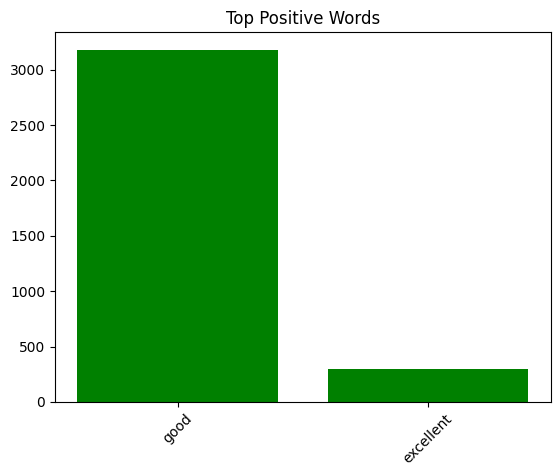

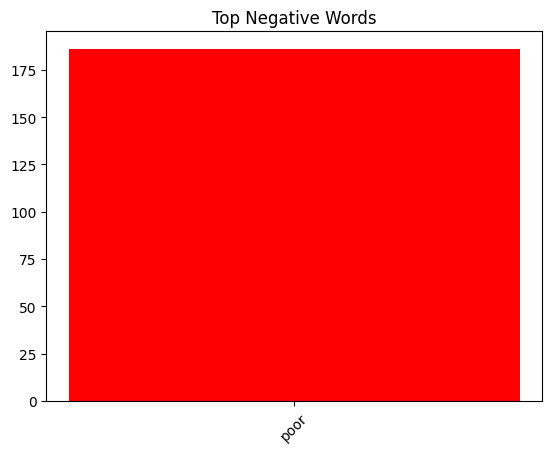

Average review length: 1.3378703800649148


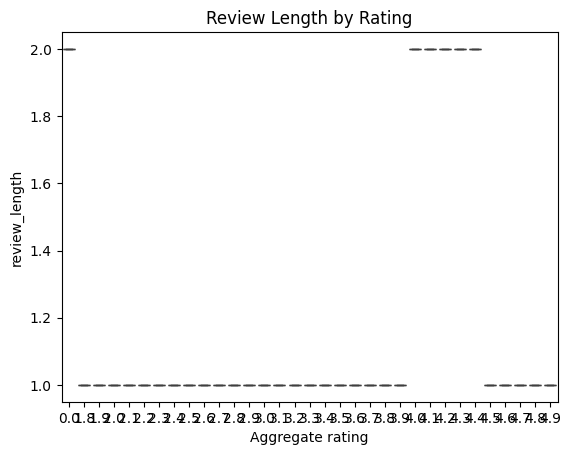

Correlation: -0.5995731124014931


In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, opinion_lexicon
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

#LEVEL 3:TASK 1-Restaurants Review

# Load your data
df = pd.read_csv('Dataset .csv')

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('opinion_lexicon')
nltk.download('punkt_tab') # Added download for punkt_tab

# Use 'Rating text' column
text_column = 'Rating text'

# Clean the text
def clean_text(text):
    words = word_tokenize(str(text).lower())
    words = [w for w in words if w.isalpha()]
    words = [w for w in words if w not in stopwords.words('english')]
    return words

# Checking if column exists
if text_column in df.columns:
    df['tokens'] = df[text_column].apply(clean_text)
    print(df[[text_column, 'tokens']].head())

    #Keywords for negative and positive analysis
    positive = set(opinion_lexicon.positive())
    negative = set(opinion_lexicon.negative())

    def get_sentiment_words(words):
        pos = [w for w in words if w in positive]
        neg = [w for w in words if w in negative]
        return pos, neg

    df['pos_words'], df['neg_words'] = zip(*df['tokens'].apply(get_sentiment_words))

    # Count common words
    pos_count = Counter([w for words in df['pos_words'] for w in words])
    neg_count = Counter([w for words in df['neg_words'] for w in words])

    print("Top Positive Words:", pos_count.most_common(10))
    print("Top Negative Words:", neg_count.most_common(10))

    # Visualize
    plt.bar(*zip(*pos_count.most_common(10)), color='green')
    plt.title("Top Positive Words")
    plt.xticks(rotation=45)
    plt.show()

    plt.bar(*zip(*neg_count.most_common(10)), color='red')
    plt.title("Top Negative Words")
    plt.xticks(rotation=45)
    plt.show()

    # Analyzing the length
    df['review_length'] = df[text_column].apply(lambda x: len(str(x).split()))
    print("Average review length:", df['review_length'].mean())

    if 'Aggregate rating' in df.columns:
        sns.boxplot(x='Aggregate rating', y='review_length', data=df)
        plt.title("Review Length by Rating")
        plt.show()

        print("Correlation:", df['review_length'].corr(df['Aggregate rating']))
    else:
        print("Column 'Aggregate rating' not found.")
else:
    print(f"Column '{text_column}' not found in dataset.")

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64
Highest Votes:
     Restaurant Name  Votes  Aggregate rating
728            Toit  10934               4.8

Lowest Votes:
                  Restaurant Name  Votes  Aggregate rating
69              Cantinho da Gula      0               0.0
874                The Chaiwalas      0               0.0
879           Fusion Food Corner      0               0.0
880                Punjabi Rasoi      0               0.0
887                Baskin Rob

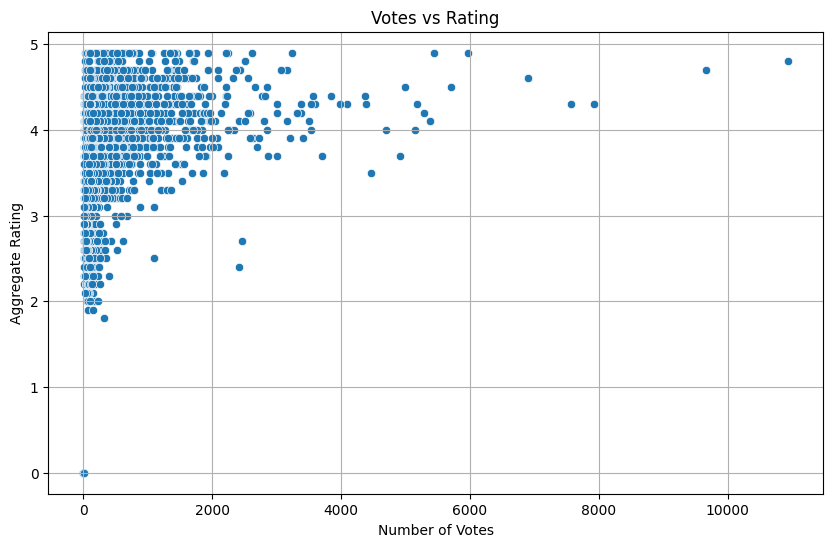

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Dataset .csv')
df.columns

#LEVEL 3:TASK 2-Votes Analysis
#Aggregate Rating
#Votes

# Checking for missing values
print(df.isnull().sum())
df_clean = df.dropna(subset=['Votes', 'Aggregate rating'])

df_clean['Votes'] = pd.to_numeric(df_clean['Votes'], errors='coerce')
df_clean['Aggregate rating'] = pd.to_numeric(df_clean['Aggregate rating'], errors='coerce')
df_clean = df_clean.dropna(subset=['Votes', 'Aggregate rating'])

#Finding the Restaurant with highest votes
highest_votes = df_clean[df_clean['Votes'] == df_clean['Votes'].max()]
print("Highest Votes:\n", highest_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

#Finding the Restaurant with lowest votes
lowest_votes = df_clean[df_clean['Votes'] == df_clean['Votes'].min()]
print("\nLowest Votes:\n", lowest_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

correlation = df_clean['Votes'].corr(df_clean['Aggregate rating'])
print(f"\nCorrelation between Votes and Rating: {correlation:.2f}")

#to make the visualisation for the analysis of the data done
plt.figure(figsize=(10,6))
sns.scatterplot(x='Votes', y='Aggregate rating', data=df_clean)
plt.title('Votes vs Rating')
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')
plt.grid(True)
plt.show()

   Price range Has Online delivery Has Table booking
0            3                  No               Yes
1            3                  No               Yes
2            4                  No               Yes
3            4                  No                No
4            4                  No               Yes
Average availability by price range:
   Price range  Online_Delivery_Flag  Table_Booking_Flag
0            1              0.157741            0.000225
1            2              0.413106            0.076775
2            3              0.291903            0.457386
3            4              0.090444            0.467577


/tmp/ipython-input-23-2313008222.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x='Price range', y='Online_Delivery_Flag', palette='Blues')


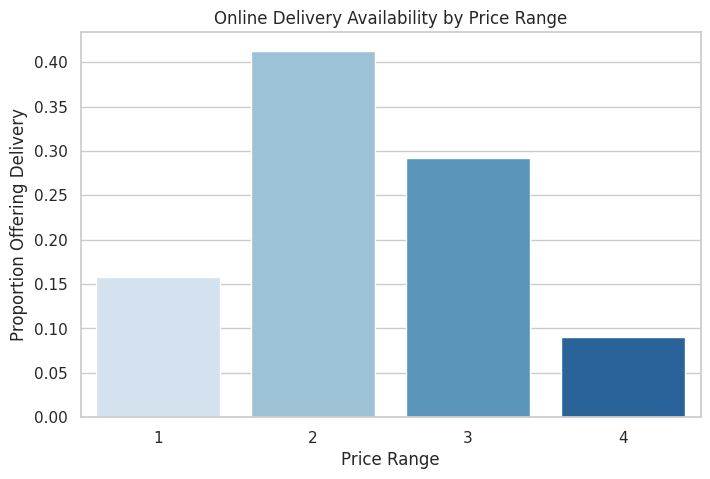

/tmp/ipython-input-23-2313008222.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x='Price range', y='Table_Booking_Flag', palette='Greens')


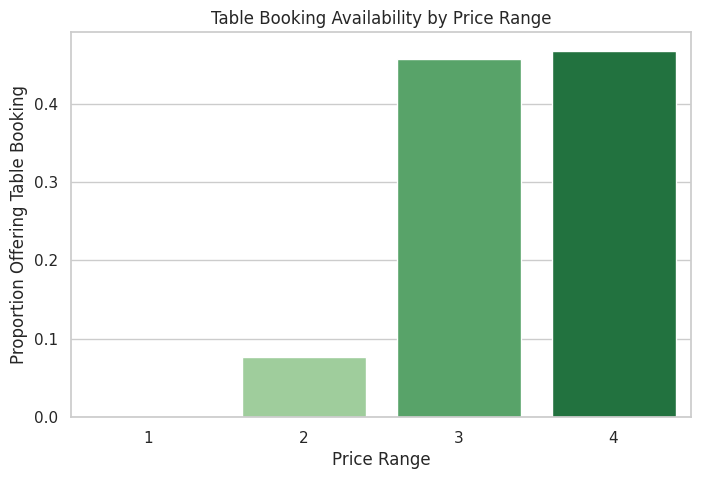

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Dataset .csv')

#LEVEL 3:TASK 3-Price Range vs. Online delivery vs. Table bookings

# Checking the relevant columns
print(df[['Price range', 'Has Online delivery', 'Has Table booking']].head())

df['Online_Delivery_Flag'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})
df['Table_Booking_Flag'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})

# Grouping by price range
grouped = df.groupby('Price range')[['Online_Delivery_Flag', 'Table_Booking_Flag']].mean().reset_index()

print("Average availability by price range:")
print(grouped)

# Setting the style
sns.set(style="whitegrid")

# Online Delivery vs. Price Range
plt.figure(figsize=(8,5))
sns.barplot(data=grouped, x='Price range', y='Online_Delivery_Flag', palette='Blues')
plt.title('Online Delivery Availability by Price Range')
plt.ylabel('Proportion Offering Delivery')
plt.xlabel('Price Range')
plt.show()

# Table Booking vs. Price Range
plt.figure(figsize=(8,5))
sns.barplot(data=grouped, x='Price range', y='Table_Booking_Flag', palette='Greens')
plt.title('Table Booking Availability by Price Range')
plt.ylabel('Proportion Offering Table Booking')
plt.xlabel('Price Range')
plt.show()
